In [1]:
import numpy as np

import pandas as pd
import copy
import math
from collections import OrderedDict, Counter
#from multiprocessing import Pool
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint

In [2]:
_Data_PATH_XX_ = './simulation_results/'
_Figure_PATH_XX_ = './figures/'

In [3]:
N = 10000
Edge = 20000
#N = 500
#Edge = 1000
beta = 0.04
r = 0.1 #代表r-1
v = 2.4 #非线性传播指数
h = 0.25#代表r_2
m = 3  #超边大小
mu = 0.2 #恢复概率
#n0_list = [90,2700]
n0_list = [300,9000]
#n0_list = [15,450]
#n0_list = [30,900]
#n0 = 9000
lam = 1 # 选到S的可能性比例
T = np.linspace(0, 1000, num = int(1000 / 0.1))#运行总时间
#beta_list = [0.001*i for i in range(101)]
#beta_list = [0.0001*i for i in range(301)]
beta_list = [0.00025*i for i in range(201)]
#beta_list = [0.02+0.00001*i for i in range(601)]

In [4]:
#filename = 'test'+'N'+str(N)+'Edge' + str(Edge) + '_v'+ str(v) + '_r' + str(r) + '_h' + str(h) + '_p' +str(lam) +'_mu'+str(mu)+'n0'+str(n0)
#rho_dict = np.load(_Data_PATH_XX_ + filename + '.npy',allow_pickle=True).item()
#print(rho_dict)

In [5]:
#filename = 'Edge' + str(Edge) + '_v'+ str(v) + '_r' + str(r) + '_h' + str(h) + '_p' +str(lam) +'_mu'+str(mu)
#仿真结果导入
average_results = {}
i =0
for n0 in n0_list:
    filename ='arb_ada_kernel_testN'+str(N)+'Edge' + str(Edge) + '_v'+ str(v) + '_r' + str(r) + '_h' + str(h) + '_p' +str(lam) +'_mu'+str(mu)+'n0'+str(n0)
    rho_dict = np.load(_Data_PATH_XX_ + filename + '.npy',allow_pickle=True).item()
    #print(rho_dict)
    average_results[i]=[]
    beta_list_simu = []
    for key, value in rho_dict.items():
        beta_list_simu.append(key)
        average_results[i].append(np.mean(value)/N)
    i = i + 1

In [6]:
# 定义非线性传播函数 i<m
def F(beta, v, i):
    return beta * (i ** v)
# 定义非线性重连函数 : i<m
"""def W(r, h, i):
    return r * (i ** h)"""
#在新的函数中r表示r1, h不是非线性增强参数了而是表示直接给定的r2
def W(r, h, i):
    temp = r
    if i == 1:
        temp = r
    else:
        temp = h
    return temp

# 给定S，被感染的概率近似为(3-uniform hypergraph)
def Theta(beta,v,l_1,l_2, m, N,i):
    prob = l_1 * (m-1) * F(beta, v, 1)/(N-i) + l_2 * (m-2) * F(beta, v, 2)/(N-i)
    return prob

#选择未感染者的概率 lam = 1时为随机选择
def Select_S(N,i,lam):
    prob = lam*(N-i) /(lam*(N-i)+i)
    return prob

In [7]:
# nonlinear adaptivity of 3-uniform hypergraph 
def evo_eq(f, t, parameters):
    # infected: 感染者数量
    # l_i: 边内有i个感染者的超边数量
    i, l_0, l_1, l_2 = f
    
    # 参数组合
    N, Edge, beta, r, v, h, m, lam, mu = parameters
    
    # 动力学方程 (i<2时需要停止)
    di = F(beta,v,1)*l_1*2 + F(beta,v,2)*l_2*1 - mu*i
    
    dl_0 = -l_0*m*Theta(beta,v,l_1,l_2, m, N,i) + mu * l_1 + W(r, h, 1)*l_1*Select_S(N,i,lam)*Select_S(N,i,lam) + W(r, h, 2)*l_2*Select_S(N,i,lam)*Select_S(N,i,lam)
    
    dl_1 = -F(beta,v,1)*l_1*2 - 2*l_1*Theta(beta,v,l_1,l_2, m, N,i) + 3*l_0*Theta(beta,v,l_1,l_2, m, N,i) + 2*l_2*mu - W(r, h, 1)*l_1 + W(r, h, 1)*l_1*2*Select_S(N,i,lam)*(1-Select_S(N,i,lam)) + W(r, h, 2)*l_2*2*Select_S(N,i,lam)*(1-Select_S(N,i,lam))-mu*l_1
    
    dl_2 = -F(beta,v,2)*l_2*1 - l_2*Theta(beta,v,l_1,l_2, m, N,i) + F(beta,v,1)*l_1*2 + 2*l_1*Theta(beta,v,l_1,l_2, m, N,i) + 3*mu*(Edge-l_0-l_1-l_2) - W(r, h, 2)*l_2 + W(r, h, 1)*l_1*(1-Select_S(N,i,lam))*(1-Select_S(N,i,lam)) + W(r,h, 2)*l_2*(1-Select_S(N,i,lam))*(1-Select_S(N,i,lam))-2* mu*l_2
    
    return np.array([di, dl_0, dl_1, dl_2])

In [8]:
# 定义 O点处的Jacobi 矩阵 (i,l_1,l_2,l_3) = (0,0,0,0)
"""def Jacob_matrix(N,Edge,beta,v,mu,r,h):
    J = np.zeros((4,4))
    J[0,0] = -mu
    J[0,1] = 2*beta
    J[0,2] = (2**v)*beta
    J[1,1] = -2*beta - mu + (3*Edge/N)*2*beta - r
    J[1,2] = (3*Edge/N)*(2**v)*beta + 2*mu
    J[2,1] = 2*beta
    J[2,2] = -(2**v)*beta - 2*mu - r*(2**h)
    J[2,3] = 3*mu
    J[3,2] = (2**v)*beta
    J[3,3] = -3*mu
    
    eigenvalues = np.linalg.eigvals(J)
    
    Max_value = max(eigenvalues)
    return Max_value"""

'def Jacob_matrix(N,Edge,beta,v,mu,r,h):\n    J = np.zeros((4,4))\n    J[0,0] = -mu\n    J[0,1] = 2*beta\n    J[0,2] = (2**v)*beta\n    J[1,1] = -2*beta - mu + (3*Edge/N)*2*beta - r\n    J[1,2] = (3*Edge/N)*(2**v)*beta + 2*mu\n    J[2,1] = 2*beta\n    J[2,2] = -(2**v)*beta - 2*mu - r*(2**h)\n    J[2,3] = 3*mu\n    J[3,2] = (2**v)*beta\n    J[3,3] = -3*mu\n\n    eigenvalues = np.linalg.eigvals(J)\n\n    Max_value = max(eigenvalues)\n    return Max_value'

In [9]:
"""max_eigen = []
for beta in beta_list:
    temp = Jacob_matrix(N,Edge,beta,v,mu,r,h)
    max_eigen.append(temp)
    
for i in range(len(beta_list)):
    if max_eigen[i] > 0:
        critical_value = beta_list[i-1]
        break
print(critical_value)"""

'max_eigen = []\nfor beta in beta_list:\n    temp = Jacob_matrix(N,Edge,beta,v,mu,r,h)\n    max_eigen.append(temp)\n\nfor i in range(len(beta_list)):\n    if max_eigen[i] > 0:\n        critical_value = beta_list[i-1]\n        break\nprint(critical_value)'

In [10]:
# 阈值的解析解
def thre_solution(N,Edge,v,mu,r,h):
    k_tri = 3*Edge/N
    tem = (r*(2**(h+1))*(1-k_tri)-4*mu*k_tri)**2 + (2**(v+3))*k_tri*(mu+r)*(2*mu+r*(2**h))
    
    thre_beta = (r*(2**(h+1))*(1-k_tri)-4*mu*k_tri + math.sqrt(tem))/((2**(v+2))*k_tri)
    return thre_beta

critical_value = thre_solution(N,Edge,v,mu,r,h)
print(critical_value)

0.02122755978221262


In [11]:
#Init_condition_list = [[90, Edge-556, 540, 16],[N-300, 6, 1458, 162]] # 超边总数为6000时
Init_condition_list = [[300, 18253, 1693, 52],[N-1000, 20, 540, 4860]] # 10000，20000
#Init_condition_list = [[30, 1825, 169, 5],[N-100, 2, 54, 486]] # 1000，2000
#Init_condition_list = [[15, 913, 84, 3],[N-50, 1, 27, 243]] # 500，1000

In [12]:
inf_number = {}
for i in range(2):
    Init_condition = Init_condition_list[i]
    inf_number[i] = []
    for beta in beta_list:
        parameters = [N, Edge, beta, r, v, h, m, lam, mu]
        results = odeint(evo_eq, Init_condition, T, args = (parameters,))
        inf_number[i].append(results[-1,0]/N)

#print(beta_list)

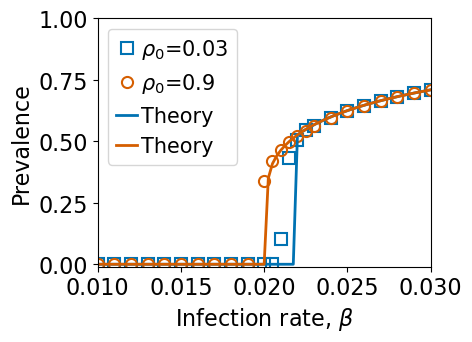

In [13]:
#画图
#color_map=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
color_map=['#0072B2', '#D55E00', '#009E73', '#E69F00']
marker_shape = ['o','d','s','d']
plt.figure(figsize=(4.5,3.5))
l1,=plt.plot(beta_list_simu, average_results[0],'s',color=color_map[0],markersize=8,markerfacecolor='none',markeredgewidth=1.5,label="$\\rho_0$=0.03")
l2,=plt.plot(beta_list_simu, average_results[1],'o',color=color_map[1],markersize=8,markerfacecolor='none',markeredgewidth=1.5,label="$\\rho_0$=0.9")

l3,=plt.plot(beta_list, inf_number[0],color=color_map[0],linewidth=2, label="Theory")
l4,=plt.plot(beta_list, inf_number[1],color=color_map[1],linewidth=2, label="Theory")
#plt.plot([critical_value,critical_value], [0,1000],color='k',linewidth=3, label="critical")

font1 = {'weight': 'normal','size':16}
font2 = {'weight': 'normal','size':15}
plt.ylim((-0.01,1))
plt.xlim((0.01,0.03))
#plt.xlim((0.012,0.016))
#plt.xlim((0.01,0.1))
#plt.xticks([0,0.02,0.04,0.06,0.08],['0','0.02','0.04','0.06','0.08'])
plt.subplots_adjust(left=0.19,bottom=0.17,right=0.93)
plt.tick_params(labelsize=16)
plt.xlabel('Infection rate, $\\beta$',font1)
plt.ylabel('Prevalence',font1)
plt.legend(prop=font2, handletextpad=0.2,handlelength=1, loc='upper left')
#legend1=plt.legend([l1,l2], ["$n_0$=0.03","$n_0$=0.9"], handletextpad=0.3,loc = 'lower right', prop=font2)
#plt.legend([l4],["Theory"], loc='upper left',handlelength=1, handletextpad=0.3, prop=font2)
#plt.gca().add_artist(legend1)
#filename = 'testp_vs_beta'+'N'+str(N)+'Edge' + str(Edge) + '_v'+ str(v) + '_r' + str(r) + '_h' + str(h) + '_p' +str(lam) +'_mu'+str(mu)
plt.savefig(_Figure_PATH_XX_ + filename + '.png', dpi = 400)
plt.show()

In [14]:
"""#plot figures
color_map=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
marker_shape = ['o','d','s','d']
plt.figure(figsize=(8,4.5))
plt.plot(beta_list, inf_number)"""


"""plt.figure(figsize=(6,4.5))
plt.plot(T, results[:,1],label="l_0")
plt.plot(T, results[:,2],label="l_1")
plt.plot(T, results[:,3],label="l_2")
plt.legend()
plt.figure(figsize=(6,4.5))
M = [Edge-results[i,1]-results[i,2]-results[i,3] for i in range(len(T))]
plt.plot(T,M)"""


'plt.figure(figsize=(6,4.5))\nplt.plot(T, results[:,1],label="l_0")\nplt.plot(T, results[:,2],label="l_1")\nplt.plot(T, results[:,3],label="l_2")\nplt.legend()\nplt.figure(figsize=(6,4.5))\nM = [Edge-results[i,1]-results[i,2]-results[i,3] for i in range(len(T))]\nplt.plot(T,M)'


#_Data_PATH_XX_ = './data/'
#filename = 'r'+str(r)+'h'+str(h)+'v'+str(v)
#np.savetxt(_Data_PATH_XX_ + filename + '.txt', inf_number)

#phase = np.loadtxt(_Data_PATH_XX_ + filename + '.txt')
#plt.plot(beta_list,phase)